In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load the Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

# Display the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Check the shape of the dataset
print("Number of rows and columns:", df.shape)

# Check the column names
print("\nColumn names:")
print(df.columns)

# Check basic information about the dataset
print("\nDataset information:")
df.info()

Number of rows and columns: (891, 12)

Column names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# Fill missing Age values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with the most common value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop columns that are not needed
df = df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1)

# Check missing values again
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [6]:
# Convert categorical columns into numerical values
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Display the first 5 rows
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [7]:
# Separate features (X) and target (y)

X = df.drop('Survived', axis=1)
y = df['Survived']

print("Features (X):")
print(X.columns)

print("\nTarget (y):")
print("Survived")

Features (X):
Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

Target (y):
Survived


In [8]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 8)
Testing data: (179, 8)


In [9]:
# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [10]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Display the first 10 predictions
print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[0 0 0 1 1 1 1 0 1 1]


In [11]:
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.8100558659217877
Accuracy Percentage: 81.00558659217877 %


In [12]:
# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[90 15]
 [19 55]]


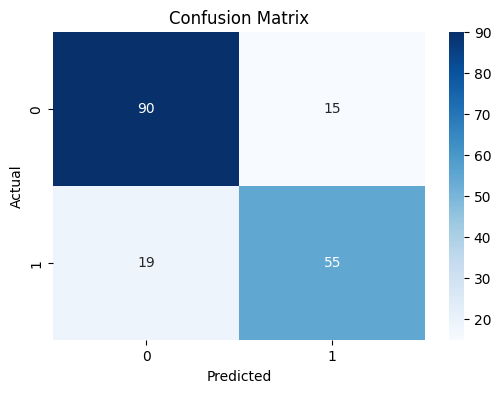

In [13]:
# Visualize the confusion matrix

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
# Generate the classification report
report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [15]:
# Conclusion

print("Conclusion:")
print("The Titanic Survival Prediction model was successfully built using Logistic Regression.")
print("The model achieved an accuracy of approximately 81%.")
print("The model uses passenger information such as passenger class, age, sex, family information, and fare")
print("to predict whether a passenger survived or did not survive.")

Conclusion:
The Titanic Survival Prediction model was successfully built using Logistic Regression.
The model achieved an accuracy of approximately 81%.
The model uses passenger information such as passenger class, age, sex, family information, and fare
to predict whether a passenger survived or did not survive.
